# Baseline Study of Short-Horizon Equity Return Dynamics

## Problem Framing

### Objective

This study investigates whether simple lagged-return features contain weak statistical structure related to next-day equity returns.

### Methodology

The analysis uses linear baseline models evaluated under chronological train-test splits and walk-forward validation in order to reduce look-ahead bias.

### Scope

This notebook is intended as an exploratory methodological study rather than a production trading system.

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

## Data Collection and Preprocessing

Historical daily OHLCV data for AAPL is downloaded from Yahoo Finance and prepared for time-series analysis.

In [2]:
data = yf.download("AAPL", start="2015-01-01")
print(len(data))
data.head()


# Import the libraries needed for data download, data manipulation, and plotting

[*********************100%***********************]  1 of 1 completed

2856


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.192604,24.659506,23.754468,24.648441,212818400
2015-01-05,23.511061,24.042134,23.325186,23.962473,257142000
2015-01-06,23.513275,23.772173,23.152587,23.575233,263188400
2015-01-07,23.842981,23.942557,23.610636,23.721276,160423600
2015-01-08,24.759081,24.816614,24.053195,24.170475,237458000


In [3]:
# Move the date from the index into a regular column
data = data.reset_index()
data = data.drop(columns=["index", "level_0"], errors="ignore")
# Preview the updated dataset
data.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2015-01-02,24.192604,24.659506,23.754468,24.648441,212818400
1,2015-01-05,23.511061,24.042134,23.325186,23.962473,257142000
2,2015-01-06,23.513275,23.772173,23.152587,23.575233,263188400
3,2015-01-07,23.842981,23.942557,23.610636,23.721276,160423600
4,2015-01-08,24.759081,24.816614,24.053195,24.170475,237458000


In [4]:
# Flatten column names in case Yahoo Finance returns a MultiIndex structure
data.columns = data.columns.get_level_values(0)

# Check that column names are now simple
data.head()

Price,Date,Close,High,Low,Open,Volume
0,2015-01-02,24.192604,24.659506,23.754468,24.648441,212818400
1,2015-01-05,23.511061,24.042134,23.325186,23.962473,257142000
2,2015-01-06,23.513275,23.772173,23.152587,23.575233,263188400
3,2015-01-07,23.842981,23.942557,23.610636,23.721276,160423600
4,2015-01-08,24.759081,24.816614,24.053195,24.170475,237458000


In [5]:
# Convert the Date column to datetime format and sort the dataset chronologically
data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values("Date").reset_index(drop=True)

# Preview the cleaned time-ordered dataset
data.head()

Price,Date,Close,High,Low,Open,Volume
0,2015-01-02,24.192604,24.659506,23.754468,24.648441,212818400
1,2015-01-05,23.511061,24.042134,23.325186,23.962473,257142000
2,2015-01-06,23.513275,23.772173,23.152587,23.575233,263188400
3,2015-01-07,23.842981,23.942557,23.610636,23.721276,160423600
4,2015-01-08,24.759081,24.816614,24.053195,24.170475,237458000


In [6]:
# Check the time coverage of the dataset
data["Date"].min(), data["Date"].max()

(Timestamp('2015-01-02 00:00:00'), Timestamp('2026-05-12 00:00:00'))

## Preliminary Data Inspection

In [7]:
# Inspect the dataset structure, variable types, and non-null counts
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2856 entries, 0 to 2855
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2856 non-null   datetime64[ns]
 1   Close   2856 non-null   float64       
 2   High    2856 non-null   float64       
 3   Low     2856 non-null   float64       
 4   Open    2856 non-null   float64       
 5   Volume  2856 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 134.0 KB


In [8]:
# Check for missing values in each column
data.isna().sum()

Price
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

## Exploratory Data Analysis

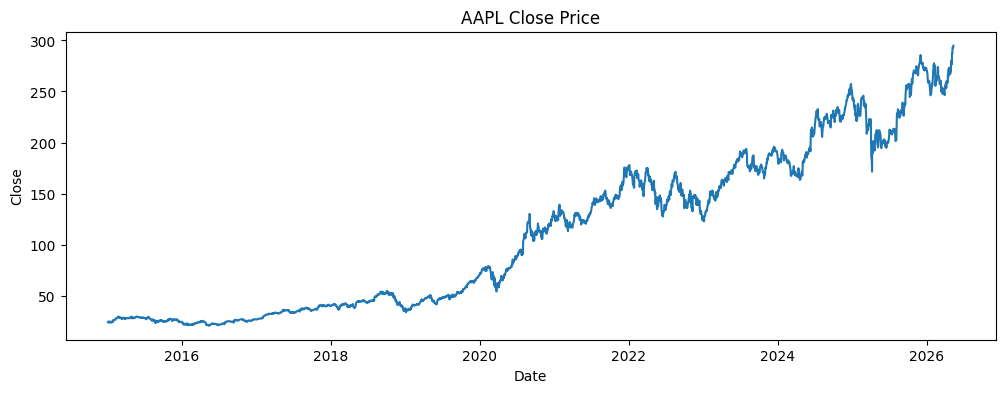

In [9]:
# Plot the closing price over time to visualize the overall price evolution
plt.figure(figsize=(12, 4))
plt.plot(data["Date"], data["Close"])
plt.title("AAPL Close Price")
plt.xlabel("Date")
plt.ylabel("Close")
plt.show()

In [10]:
# Compute daily returns from closing prices
data["ret"] = data["Close"].pct_change()



In [11]:
# Display the first rows with returns
data[["Date", "Close", "ret"]].head(10)

Price,Date,Close,ret
0,2015-01-02,24.192604,NaN
1,2015-01-05,23.511061,-0.028172
2,2015-01-06,23.513275,0.000094
3,2015-01-07,23.842981,0.014022
4,2015-01-08,24.759081,0.038422
5,2015-01-09,24.785633,0.001072
6,2015-01-12,24.174902,-0.024641
7,2015-01-13,24.389542,0.008879
8,2015-01-14,24.296606,-0.003810
9,2015-01-15,23.637190,-0.027140


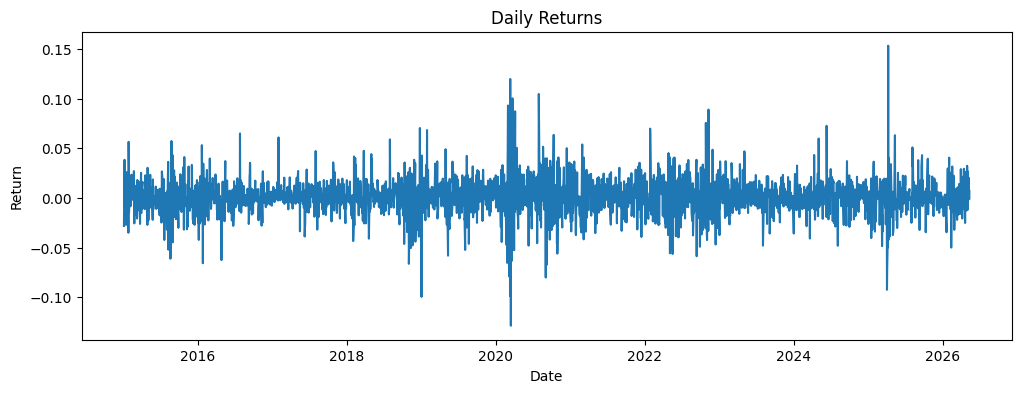

In [12]:
# Plot daily returns to visualize their time evolution
plt.figure(figsize=(12, 4))
plt.plot(data["Date"], data["ret"])
plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()

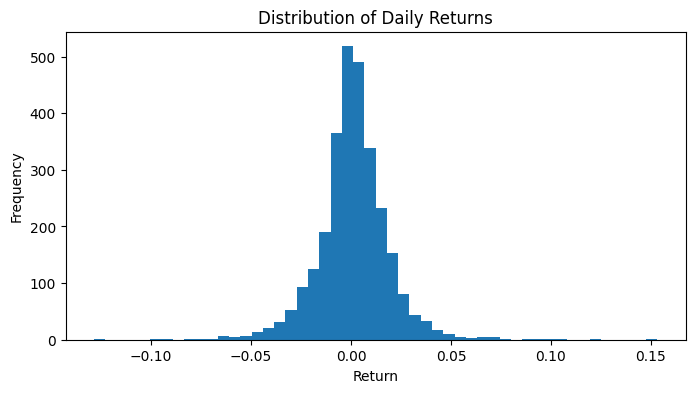

In [13]:
# Plot the distribution of daily returns to understand their overall shape
plt.figure(figsize=(8, 4))
plt.hist(data["ret"].dropna(), bins=50)
plt.title("Distribution of Daily Returns")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.show()

## Feature Engineering

### Rolling Mean Feature

In [14]:
# Compute a short rolling mean of returns as a simple smoothing / momentum-style feature
data["rolling_mean_5"] = data["ret"].rolling(5).mean()

# Display the new feature
data[["Date", "ret", "rolling_mean_5"]].head(10)

Price,Date,ret,rolling_mean_5
0,2015-01-02,NaN,NaN
1,2015-01-05,-0.028172,NaN
2,2015-01-06,0.000094,NaN
3,2015-01-07,0.014022,NaN
4,2015-01-08,0.038422,NaN
5,2015-01-09,0.001072,0.005088
6,2015-01-12,-0.024641,0.005794
7,2015-01-13,0.008879,0.007551
8,2015-01-14,-0.003810,0.003984
9,2015-01-15,-0.027140,-0.009128


### Lagged Return Features

In [15]:
# Create lagged return features to capture short-term temporal dependencies
data["lag1"] = data["ret"].shift(1)
data["lag2"] = data["ret"].shift(2)
data["lag3"] = data["ret"].shift(3)

# Display the lagged features
data[["Date", "ret", "lag1", "lag2", "lag3"]].head(10)

Price,Date,ret,lag1,lag2,lag3
0,2015-01-02,NaN,NaN,NaN,NaN
1,2015-01-05,-0.028172,NaN,NaN,NaN
2,2015-01-06,0.000094,-0.028172,NaN,NaN
3,2015-01-07,0.014022,0.000094,-0.028172,NaN
4,2015-01-08,0.038422,0.014022,0.000094,-0.028172
5,2015-01-09,0.001072,0.038422,0.014022,0.000094
6,2015-01-12,-0.024641,0.001072,0.038422,0.014022
7,2015-01-13,0.008879,-0.024641,0.001072,0.038422
8,2015-01-14,-0.003810,0.008879,-0.024641,0.001072
9,2015-01-15,-0.027140,-0.003810,0.008879,-0.024641


### Rolling Volatility Feature

In [16]:
# Compute rolling 20-day volatility as a proxy for the recent volatility regime
data["rolling_std_20"] = data["ret"].rolling(20).std()

# Display the volatility feature
data[["Date", "ret", "rolling_std_20"]].head(25)

Price,Date,ret,rolling_std_20
0,2015-01-02,NaN,NaN
1,2015-01-05,-0.028172,NaN
2,2015-01-06,0.000094,NaN
3,2015-01-07,0.014022,NaN
4,2015-01-08,0.038422,NaN
5,2015-01-09,0.001072,NaN
6,2015-01-12,-0.024641,NaN
7,2015-01-13,0.008879,NaN
8,2015-01-14,-0.003810,NaN
9,2015-01-15,-0.027140,NaN


### Prediction Target
The prediction target is defined as the next-day return.

In [17]:
# Define the prediction target as the next-day return
data["target"] = data["ret"].shift(-1)

# Display the main modeling columns
data[["Date", "ret", "lag1", "lag2", "lag3", "rolling_std_20", "target"]].head(25)

Price,Date,ret,lag1,lag2,lag3,rolling_std_20,target
0,2015-01-02,NaN,NaN,NaN,NaN,NaN,-0.028172
1,2015-01-05,-0.028172,NaN,NaN,NaN,NaN,0.000094
2,2015-01-06,0.000094,-0.028172,NaN,NaN,NaN,0.014022
3,2015-01-07,0.014022,0.000094,-0.028172,NaN,NaN,0.038422
4,2015-01-08,0.038422,0.014022,0.000094,-0.028172,NaN,0.001072
5,2015-01-09,0.001072,0.038422,0.014022,0.000094,NaN,-0.024641
6,2015-01-12,-0.024641,0.001072,0.038422,0.014022,NaN,0.008879
7,2015-01-13,0.008879,-0.024641,0.001072,0.038422,NaN,-0.003810
8,2015-01-14,-0.003810,0.008879,-0.024641,0.001072,NaN,-0.027140
9,2015-01-15,-0.027140,-0.003810,0.008879,-0.024641,NaN,-0.007770


In [18]:
# Check how many missing values were created by returns, lags, rolling windows, and target shifting
data.isna().sum()

Price
Date               0
Close              0
High               0
Low                0
Open               0
Volume             0
ret                1
rolling_mean_5     5
lag1               2
lag2               3
lag3               4
rolling_std_20    20
target             1
dtype: int64

In [19]:
# Remove rows with missing values so the dataset is ready for modeling
data = data.dropna().reset_index(drop=True)

# Preview the cleaned modeling dataset
data.head()

Price,Date,Close,High,Low,Open,Volume,ret,rolling_mean_5,lag1,lag2,lag3,rolling_std_20,target
0,2015-02-02,26.250519,26.370011,25.686254,26.122177,250956400,0.012547,0.010113,-0.014634,0.031134,0.056533,0.023813,0.000168
1,2015-02-03,26.254934,26.352297,26.024802,26.221742,207662800,0.000168,0.017150,0.012547,-0.014634,0.031134,0.022588,0.007670
2,2015-02-04,26.456303,26.666520,26.179702,26.221746,280598800,0.007670,0.007377,0.000168,0.012547,-0.014634,0.022551,0.007138
3,2015-02-05,26.645140,26.709565,26.491853,26.662911,168984800,0.007138,0.002578,0.007670,0.000168,0.012547,0.022477,-0.008421
4,2015-02-06,26.420755,26.713998,26.314121,26.662902,174826400,-0.008421,0.003820,0.007138,0.007670,0.000168,0.021310,0.006643


In [20]:
# Display the final set of variables that will be used for modeling
data[["Date", "ret", "lag1", "lag2", "lag3", "rolling_std_20", "target"]].head(10)

Price,Date,ret,lag1,lag2,lag3,rolling_std_20,target
0,2015-02-02,0.012547,-0.014634,0.031134,0.056533,0.023813,0.000168
1,2015-02-03,0.000168,0.012547,-0.014634,0.031134,0.022588,0.007670
2,2015-02-04,0.007670,0.000168,0.012547,-0.014634,0.022551,0.007138
3,2015-02-05,0.007138,0.007670,0.000168,0.012547,0.022477,-0.008421
4,2015-02-06,-0.008421,0.007138,0.007670,0.000168,0.021310,0.006643
5,2015-02-09,0.006643,-0.008421,0.007138,0.007670,0.021313,0.019211
6,2015-02-10,0.019211,0.006643,-0.008421,0.007138,0.020479,0.023439
7,2015-02-11,0.023439,0.019211,0.006643,-0.008421,0.020844,0.012653
8,2015-02-12,0.012653,0.023439,0.019211,0.006643,0.020734,0.004903
9,2015-02-13,0.004903,0.012653,0.023439,0.019211,0.019090,0.005902


In [21]:
# Check the final shape of the dataset after preprocessing
print(data.shape)

(2835, 13)


In [22]:
# Check missing values before preparing the modeling dataset
data.isna().sum()

Price
Date              0
Close             0
High              0
Low               0
Open              0
Volume            0
ret               0
rolling_mean_5    0
lag1              0
lag2              0
lag3              0
rolling_std_20    0
target            0
dtype: int64

### Missing Value Handling
Missing values generated by rolling computations and target shifting are removed before model training.

In [23]:
# Remove rows with missing values created by returns, lags, rolling volatility, and target shifting
data = data.dropna().reset_index(drop=True)

# Preview the cleaned dataset
data.head()

Price,Date,Close,High,Low,Open,Volume,ret,rolling_mean_5,lag1,lag2,lag3,rolling_std_20,target
0,2015-02-02,26.250519,26.370011,25.686254,26.122177,250956400,0.012547,0.010113,-0.014634,0.031134,0.056533,0.023813,0.000168
1,2015-02-03,26.254934,26.352297,26.024802,26.221742,207662800,0.000168,0.017150,0.012547,-0.014634,0.031134,0.022588,0.007670
2,2015-02-04,26.456303,26.666520,26.179702,26.221746,280598800,0.007670,0.007377,0.000168,0.012547,-0.014634,0.022551,0.007138
3,2015-02-05,26.645140,26.709565,26.491853,26.662911,168984800,0.007138,0.002578,0.007670,0.000168,0.012547,0.022477,-0.008421
4,2015-02-06,26.420755,26.713998,26.314121,26.662902,174826400,-0.008421,0.003820,0.007138,0.007670,0.000168,0.021310,0.006643


In [24]:
# Display the final columns that will be used in the modeling stage
data[["Date", "ret", "lag1", "lag2", "lag3", "rolling_std_20", "target"]].head(10)

Price,Date,ret,lag1,lag2,lag3,rolling_std_20,target
0,2015-02-02,0.012547,-0.014634,0.031134,0.056533,0.023813,0.000168
1,2015-02-03,0.000168,0.012547,-0.014634,0.031134,0.022588,0.007670
2,2015-02-04,0.007670,0.000168,0.012547,-0.014634,0.022551,0.007138
3,2015-02-05,0.007138,0.007670,0.000168,0.012547,0.022477,-0.008421
4,2015-02-06,-0.008421,0.007138,0.007670,0.000168,0.021310,0.006643
5,2015-02-09,0.006643,-0.008421,0.007138,0.007670,0.021313,0.019211
6,2015-02-10,0.019211,0.006643,-0.008421,0.007138,0.020479,0.023439
7,2015-02-11,0.023439,0.019211,0.006643,-0.008421,0.020844,0.012653
8,2015-02-12,0.012653,0.023439,0.019211,0.006643,0.020734,0.004903
9,2015-02-13,0.004903,0.012653,0.023439,0.019211,0.019090,0.005902


# Predictive Modeling
The feature matrix consists of lagged returns and rolling volatility features.

In [25]:
# Define the feature matrix X and the prediction target y
features = ["lag1", "lag2", "lag3", "rolling_std_20"]

X = data[features]
y = data["target"]

# Check the shapes of X and y
print(X.shape)
print(y.shape)

(2835, 4)
(2835,)


### Chronological Train-Test Split

In [26]:
# Create a chronological train-test split to avoid look-ahead bias
split_index = int(len(data) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

# Check the size of each split
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (2268, 4)
X_test : (567, 4)
y_train: (2268,)
y_test : (567,)


### Baseline Linear Models

In [27]:
# Import linear models and numpy for model training and evaluation
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [28]:
def safe_corr(pred, y):
    if np.std(pred) == 0 or np.std(y) == 0:
        return np.nan
    return np.corrcoef(pred, y)[0, 1]

In [29]:
# Train an OLS model (Linear Regression) on the training set
model_ols = LinearRegression()
model_ols.fit(X_train, y_train)

# Generate test predictions
pred_ols = model_ols.predict(X_test)

In [30]:
# Measure the correlation between OLS predictions and realized returns
corr_ols = np.corrcoef(pred_ols, y_test)[0, 1]
print("OLS correlation:", corr_ols)

OLS correlation: 0.06702155649133314


In [31]:
# Train a Ridge regression model to test whether L2 regularization improves stability
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train, y_train)

# Generate test predictions
pred_ridge = model_ridge.predict(X_test)

### Model Comparison

In [32]:
# Measure the correlation between Ridge predictions and realized returns
corr_ridge = np.corrcoef(pred_ridge, y_test)[0, 1]
print("Ridge correlation:", corr_ridge)

Ridge correlation: 0.07349634949895066


In [33]:
# Train a Lasso regression model to test whether sparse regularization changes the result
model_lasso = Lasso(alpha=0.001)
model_lasso.fit(X_train, y_train)

# Generate test predictions
pred_lasso = model_lasso.predict(X_test)

In [34]:
# Measure the correlation between Lasso predictions and realized returns
# Sparse regularization may collapse predictions toward a nearly constant value
# under weak signal conditions.

if np.std(pred_lasso) < 1e-10:
    corr_lasso = 0.0
    print("Lasso correlation: undefined (predictions collapsed toward a constant value)")
else:
    corr_lasso = safe_corr(pred_lasso, y_test)
    print("Lasso correlation:", corr_lasso)

Lasso correlation: undefined (predictions collapsed toward a constant value)


In [35]:
# Compare the three models using the same evaluation metric
results_models = pd.DataFrame({
    "Model": ["OLS", "Ridge", "Lasso"],
    "Correlation": [corr_ols, corr_ridge, corr_lasso]
})

results_models

,Model,Correlation
0,OLS,0.067022
1,Ridge,0.073496
2,Lasso,0.000000


### Lag Structure Analysis

Different lag combinations are evaluated to assess whether additional lagged-return information improves out-of-sample correlation.

In [36]:
# Test predictive performance using only lag1
features_lag1 = ["lag1"]

X1 = data[features_lag1]
y1 = data["target"]

X1_train = X1.iloc[:split_index]
X1_test  = X1.iloc[split_index:]
y1_train = y1.iloc[:split_index]
y1_test  = y1.iloc[split_index:]

model_lag1 = Ridge(alpha=1.0)
model_lag1.fit(X1_train, y1_train)
pred_lag1 = model_lag1.predict(X1_test)

corr_lag1 = np.corrcoef(pred_lag1, y1_test)[0, 1]
print("Ridge with lag1:", corr_lag1)

Ridge with lag1: -0.06385389454517368


In [37]:
# Test predictive performance using lag1 and lag2
features_lag12 = ["lag1", "lag2"]

X12 = data[features_lag12]
y12 = data["target"]

X12_train = X12.iloc[:split_index]
X12_test  = X12.iloc[split_index:]
y12_train = y12.iloc[:split_index]
y12_test  = y12.iloc[split_index:]

model_lag12 = Ridge(alpha=1.0)
model_lag12.fit(X12_train, y12_train)
pred_lag12 = model_lag12.predict(X12_test)

corr_lag12 = np.corrcoef(pred_lag12, y12_test)[0, 1]
print("Ridge with lag1 + lag2:", corr_lag12)

Ridge with lag1 + lag2: 0.04854803780514557


In [38]:
# Test predictive performance using lag1, lag2, and lag3
features_lag123 = ["lag1", "lag2", "lag3"]

X123 = data[features_lag123]
y123 = data["target"]

X123_train = X123.iloc[:split_index]
X123_test  = X123.iloc[split_index:]
y123_train = y123.iloc[:split_index]
y123_test  = y123.iloc[split_index:]

model_lag123 = Ridge(alpha=1.0)
model_lag123.fit(X123_train, y123_train)
pred_lag123 = model_lag123.predict(X123_test)

corr_lag123 = np.corrcoef(pred_lag123, y123_test)[0, 1]
print("Ridge with lag1 + lag2 + lag3:", corr_lag123)

Ridge with lag1 + lag2 + lag3: 0.07473899926592088


In [39]:
# Compare predictive performance across different lag structures
results_lags = pd.DataFrame({
    "Feature_Set": ["lag1", "lag1 + lag2", "lag1 + lag2 + lag3"],
    "Correlation": [corr_lag1, corr_lag12, corr_lag123]
})

results_lags

,Feature_Set,Correlation
0,lag1,-0.063854
1,lag1 + lag2,0.048548
2,lag1 + lag2 + lag3,0.074739


## Volatility Feature Impact

We compare:
- lagged return features only
- lagged returns + rolling volatility

Goal: Evaluate whether volatility information improves predictive performance.

In [40]:
# Compare lag-only features versus lag features plus rolling volatility
features_lags_only = ["lag1", "lag2", "lag3"]
features_lags_vol  = ["lag1", "lag2", "lag3", "rolling_std_20"]

# Lags only
X_lags = data[features_lags_only]
y_lags = data["target"]

X_lags_train = X_lags.iloc[:split_index]
X_lags_test  = X_lags.iloc[split_index:]
y_lags_train = y_lags.iloc[:split_index]
y_lags_test  = y_lags.iloc[split_index:]

model_lags = Ridge(alpha=1.0)
model_lags.fit(X_lags_train, y_lags_train)
pred_lags = model_lags.predict(X_lags_test)

corr_lags = np.corrcoef(pred_lags, y_lags_test)[0, 1]

# Lags + volatility
X_lags_vol = data[features_lags_vol]
y_lags_vol = data["target"]

X_lags_vol_train = X_lags_vol.iloc[:split_index]
X_lags_vol_test  = X_lags_vol.iloc[split_index:]
y_lags_vol_train = y_lags_vol.iloc[:split_index]
y_lags_vol_test  = y_lags_vol.iloc[split_index:]

model_lags_vol = Ridge(alpha=1.0)
model_lags_vol.fit(X_lags_vol_train, y_lags_vol_train)
pred_lags_vol = model_lags_vol.predict(X_lags_vol_test)

corr_lags_vol = np.corrcoef(pred_lags_vol, y_lags_vol_test)[0, 1]

print("Ridge with lag features only       :", corr_lags)
print("Ridge with lag features + volatility:", corr_lags_vol)

Ridge with lag features only       : 0.07473899926592088
Ridge with lag features + volatility: 0.07349634949895066


In [41]:
# Summarize the impact of adding rolling volatility to the lag-based model
results_volatility = pd.DataFrame({
    "Feature_Set": ["lag1 + lag2 + lag3", "lag1 + lag2 + lag3 + rolling_std_20"],
    "Correlation": [corr_lags, corr_lags_vol]
})

results_volatility

,Feature_Set,Correlation
0,lag1 + lag2 + lag3,0.074739
1,lag1 + lag2 + lag3 + rolling_std_20,0.073496


In [42]:
# Print a compact summary of the main results obtained so far
print("Model comparison")
print(results_models)
print()

print("Lag structure comparison")
print(results_lags)
print()

print("Volatility feature impact")
print(results_volatility)

Model comparison
   Model  Correlation
0    OLS     0.067022
1  Ridge     0.073496
2  Lasso     0.000000

Lag structure comparison
          Feature_Set  Correlation
0                lag1    -0.063854
1         lag1 + lag2     0.048548
2  lag1 + lag2 + lag3     0.074739

Volatility feature impact
                           Feature_Set  Correlation
0                   lag1 + lag2 + lag3     0.074739
1  lag1 + lag2 + lag3 + rolling_std_20     0.073496


## Walk-Forward Validation

The model is evaluated through expanding training windows and yearly out-of-sample test periods to assess signal stability over time.

In [43]:
# Select the feature set used in the walk-forward validation
features_wf = ["lag1", "lag2", "lag3", "rolling_std_20"]

X_wf = data[features_wf]
y_wf = data["target"]
dates_wf = data["Date"]

In [44]:
# Define a sequence of expanding training windows and one-year test windows
# Each tuple is: (train_end_date, test_start_date, test_end_date)
walk_forward_windows = [
    ("2018-12-31", "2019-01-01", "2019-12-31"),
    ("2019-12-31", "2020-01-01", "2020-12-31"),
    ("2020-12-31", "2021-01-01", "2021-12-31"),
    ("2021-12-31", "2022-01-01", "2022-12-31"),
    ("2022-12-31", "2023-01-01", "2023-12-31")
]

walk_forward_windows

[('2018-12-31', '2019-01-01', '2019-12-31'),
 ('2019-12-31', '2020-01-01', '2020-12-31'),
 ('2020-12-31', '2021-01-01', '2021-12-31'),
 ('2021-12-31', '2022-01-01', '2022-12-31'),
 ('2022-12-31', '2023-01-01', '2023-12-31')]

In [45]:
# Create an empty list to store walk-forward results for each model and each test window
wf_results = []

In [46]:
# Run walk-forward validation across multiple time windows
for train_end, test_start, test_end in walk_forward_windows:
    
    # Create chronological train and test masks
    train_mask = dates_wf <= pd.to_datetime(train_end)
    test_mask = (dates_wf >= pd.to_datetime(test_start)) & (dates_wf <= pd.to_datetime(test_end))
    
    # Extract train and test sets
    X_train_wf = X_wf.loc[train_mask]
    y_train_wf = y_wf.loc[train_mask]
    
    X_test_wf = X_wf.loc[test_mask]
    y_test_wf = y_wf.loc[test_mask]
    
    # Skip empty windows if any
    if len(X_train_wf) == 0 or len(X_test_wf) == 0:
        continue
    
    # Train OLS
    model_ols_wf = LinearRegression()
    model_ols_wf.fit(X_train_wf, y_train_wf)
    pred_ols_wf = model_ols_wf.predict(X_test_wf)
    corr_ols_wf = np.corrcoef(pred_ols_wf, y_test_wf)[0, 1]
    
    # Train Ridge
    model_ridge_wf = Ridge(alpha=1.0)
    model_ridge_wf.fit(X_train_wf, y_train_wf)
    pred_ridge_wf = model_ridge_wf.predict(X_test_wf)
    corr_ridge_wf = np.corrcoef(pred_ridge_wf, y_test_wf)[0, 1]
    
    # Train Lasso
    model_lasso_wf = Lasso(alpha=0.001)
    model_lasso_wf.fit(X_train_wf, y_train_wf)
    pred_lasso_wf = model_lasso_wf.predict(X_test_wf)
    corr_lasso_wf = safe_corr(pred_lasso_wf, y_test_wf)
    
    # Store results
    wf_results.append({
        "Train_End": train_end,
        "Test_Start": test_start,
        "Test_End": test_end,
        "OLS_Correlation": corr_ols_wf,
        "Ridge_Correlation": corr_ridge_wf,
        "Lasso_Correlation": corr_lasso_wf,
        "Train_Size": len(X_train_wf),
        "Test_Size": len(X_test_wf)
    })

In [47]:
# Convert the walk-forward results into a DataFrame for easier analysis
wf_results_df = pd.DataFrame(wf_results)
wf_results_df

,Train_End,Test_Start,Test_End,OLS_Correlation,Ridge_Correlation,Lasso_Correlation,Train_Size,Test_Size
0,2018-12-31,2019-01-01,2019-12-31,0.054041,0.062036,NaN,986,252
1,2019-12-31,2020-01-01,2020-12-31,-0.086556,-0.096092,-7.381776e-17,1238,253
2,2020-12-31,2021-01-01,2021-12-31,-0.009004,-0.006107,-1.973600e-16,1491,252
3,2021-12-31,2022-01-01,2022-12-31,-0.020406,-0.025096,NaN,1743,251
4,2022-12-31,2023-01-01,2023-12-31,-0.034930,-0.021562,-2.962250e-16,1994,250


In [48]:
# Compute the average walk-forward correlation for each model
average_wf_results = pd.DataFrame({
    "Model": ["OLS", "Ridge", "Lasso"],
    "Average_Correlation": [
        wf_results_df["OLS_Correlation"].mean(),
        wf_results_df["Ridge_Correlation"].mean(),
        wf_results_df["Lasso_Correlation"].mean()
    ]
})

average_wf_results

,Model,Average_Correlation
0,OLS,-1.937114e-02
1,Ridge,-1.736418e-02
2,Lasso,-1.891342e-16


In [49]:
# Display model performance window by window to assess signal stability over time
wf_results_df[["Test_Start", "Test_End", "OLS_Correlation", "Ridge_Correlation", "Lasso_Correlation"]]

,Test_Start,Test_End,OLS_Correlation,Ridge_Correlation,Lasso_Correlation
0,2019-01-01,2019-12-31,0.054041,0.062036,NaN
1,2020-01-01,2020-12-31,-0.086556,-0.096092,-7.381776e-17
2,2021-01-01,2021-12-31,-0.009004,-0.006107,-1.973600e-16
3,2022-01-01,2022-12-31,-0.020406,-0.025096,NaN
4,2023-01-01,2023-12-31,-0.034930,-0.021562,-2.962250e-16


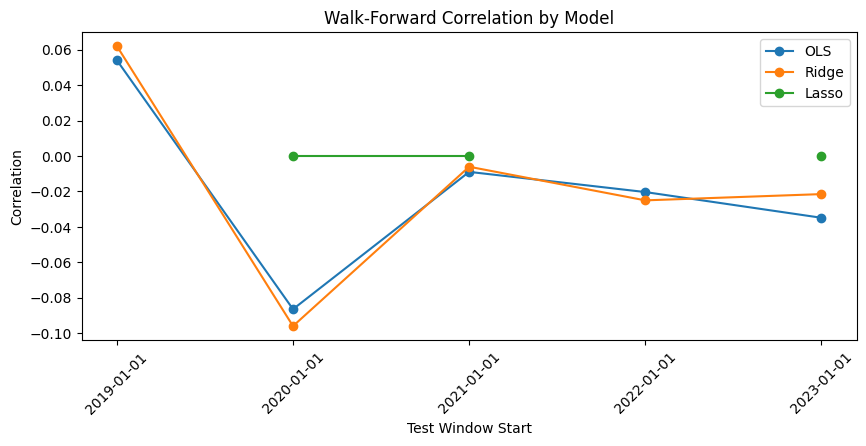

In [50]:
# Plot walk-forward correlations for all three models across test windows
plt.figure(figsize=(10, 4))
plt.plot(wf_results_df["Test_Start"], wf_results_df["OLS_Correlation"], marker="o", label="OLS")
plt.plot(wf_results_df["Test_Start"], wf_results_df["Ridge_Correlation"], marker="o", label="Ridge")
plt.plot(wf_results_df["Test_Start"], wf_results_df["Lasso_Correlation"], marker="o", label="Lasso")
plt.title("Walk-Forward Correlation by Model")
plt.xlabel("Test Window Start")
plt.ylabel("Correlation")
plt.xticks(rotation=45)
plt.legend()
plt.show()

## Results Analysis

We summarize walk-forward validation performance across models and test periods.

In [51]:
# Print a compact summary of walk-forward validation results
print("Walk-forward results by window")
print(wf_results_df[["Test_Start", "Test_End", "OLS_Correlation", "Ridge_Correlation", "Lasso_Correlation"]])
print()

print("Average walk-forward correlation")
print(average_wf_results)

Walk-forward results by window
   Test_Start    Test_End  OLS_Correlation  Ridge_Correlation  \
0  2019-01-01  2019-12-31         0.054041           0.062036   
1  2020-01-01  2020-12-31        -0.086556          -0.096092   
2  2021-01-01  2021-12-31        -0.009004          -0.006107   
3  2022-01-01  2022-12-31        -0.020406          -0.025096   
4  2023-01-01  2023-12-31        -0.034930          -0.021562   

   Lasso_Correlation  
0                NaN  
1      -7.381776e-17  
2      -1.973600e-16  
3                NaN  
4      -2.962250e-16  

Average walk-forward correlation
   Model  Average_Correlation
0    OLS        -1.937114e-02
1  Ridge        -1.736418e-02
2  Lasso        -1.891342e-16


##  Interpretation of Results

### Results show that predictive correlations between lagged returns and next-day returns remain weak across models. 
### Ridge regression slightly outperformed OLS, suggesting that mild regularization helps stabilize weak signals, while Lasso removed most predictive structure.

### Including rolling volatility did not materially improve predictive performance, suggesting that volatility alone is not sufficient to enhance short-term return predictability in this setting.

### Walk-forward validation revealed that correlations varied substantially across time windows, indicating that the signal is unstable and regime-dependent.

### Overall, results confirm that short-term equity returns are noisy and difficult to predict using simple lag-based features.

##  Limitations

  ### This study has several limitations worth acknowledging. The analysis focuses on a single asset, which limits the generalizability of any observed signal. Feature engineering was kept intentionally simple — lagged returns and rolling volatility — as the goal was hypothesis testing rather than performance optimization. No hyperparameter tuning was performed, and market regimes were not explicitly modeled, which means the results may mask structural breaks in the signal over time. Finally, only linear models were considered, leaving open the question of whether nonlinear approaches would capture additional structure. Future work could extend this framework to multi-asset datasets and explore regime-aware or nonlinear modeling approaches.


##  Conclusion
### This project explored whether simple lag-based financial features contain predictive information about next-day returns.

### Although weak correlations were detected in certain periods, results remained unstable and economically limited across time. Regularized linear models slightly improved robustness, but overall predictive power stayed low.

### The study highlights the difficulty of forecasting short-term equity returns using simple linear time-series features and emphasizes the importance of robust validation procedures in financial machine learning.
